In [1]:
"Libraries for work"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

"Visual settings"
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 14
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'DejaVu Sans'


In [2]:
df = pd.read_csv('SampleSuperstore.csv', encoding='utf-8-sig')

In [3]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [4]:
print("=== Information ===")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
print(f"\nTipos de datos:\n{df.dtypes}")
print(f"\nValores nulos:\n{df.isnull().sum()}")
print(f"\nDuplicados: {df.duplicated().sum()}")

=== Information ===
Filas: 9,994
Columnas: 13

Tipos de datos:
Ship Mode           str
Segment             str
Country             str
City                str
State               str
Postal Code       int64
Region              str
Category            str
Sub-Category        str
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

Valores nulos:
Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

Duplicados: 17


In [5]:
"Phase 1 - EDA"
"Here, we apply descriptive statistics to conduct an initial analysis of the data."

print("=== descriptive statistics ===")
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe().round(2)

=== descriptive statistics ===


,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,3.79,0.16,28.66
std,623.25,2.23,0.21,234.26
min,0.44,1.00,0.00,-6599.98
25%,17.28,2.00,0.00,1.73
50%,54.49,3.00,0.20,8.67
75%,209.94,5.00,0.20,29.36
max,22638.48,14.00,0.80,8399.98


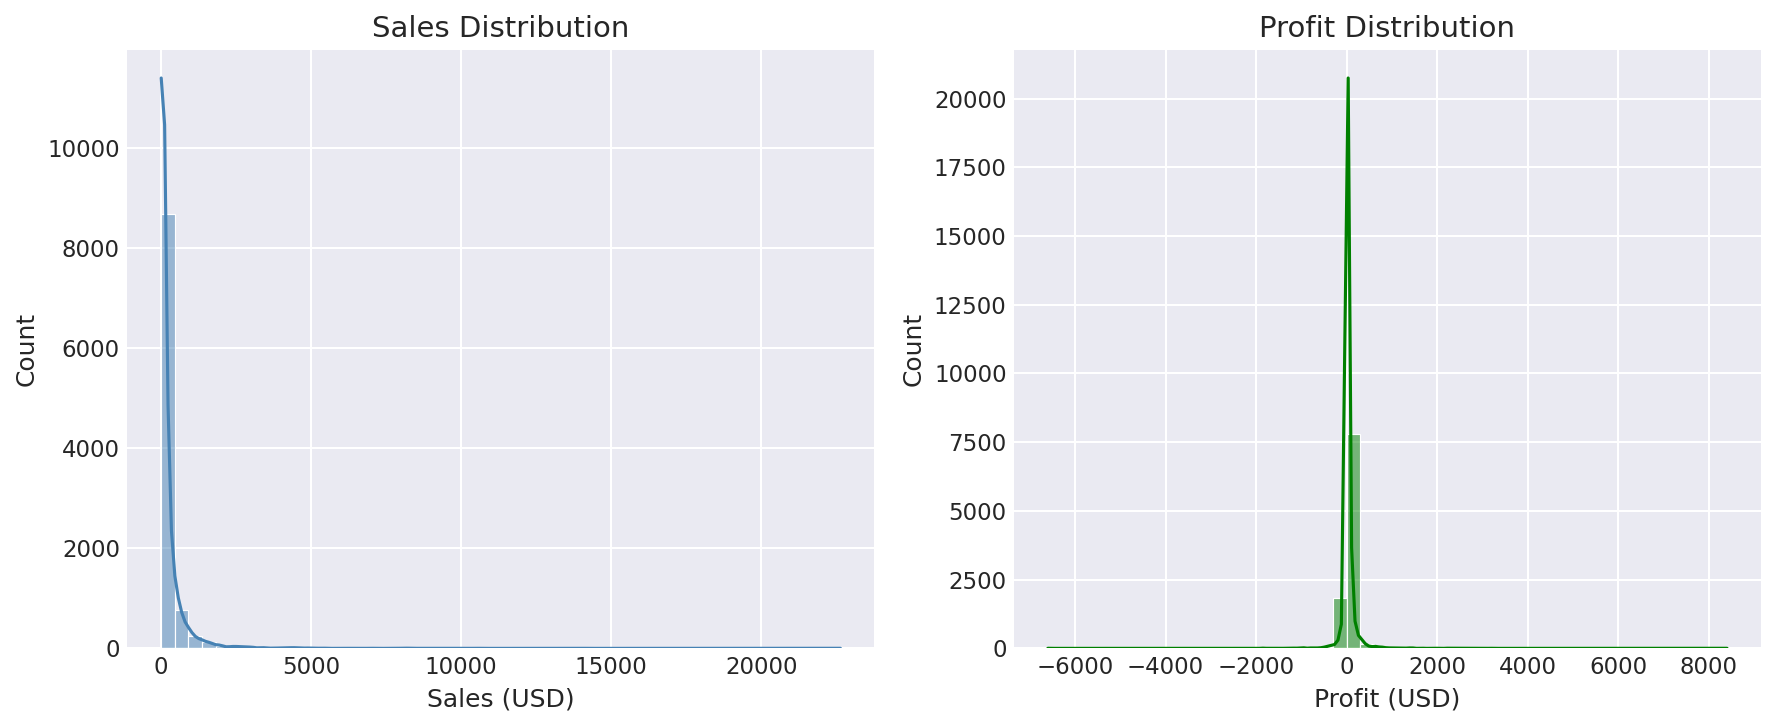

In [6]:
"We want to display the relationship between profit and sales using a histogram."

fig, axes = plt.subplots(1, 2)

sns.histplot(df['Sales'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Sales Distribution')
axes[0].set_xlabel('Sales (USD)')

sns.histplot(df['Profit'], bins=50, kde=True, ax=axes[1], color='green')
axes[1].set_title('Profit Distribution')
axes[1].set_xlabel('Profit (USD)')

plt.tight_layout()
plt.show()

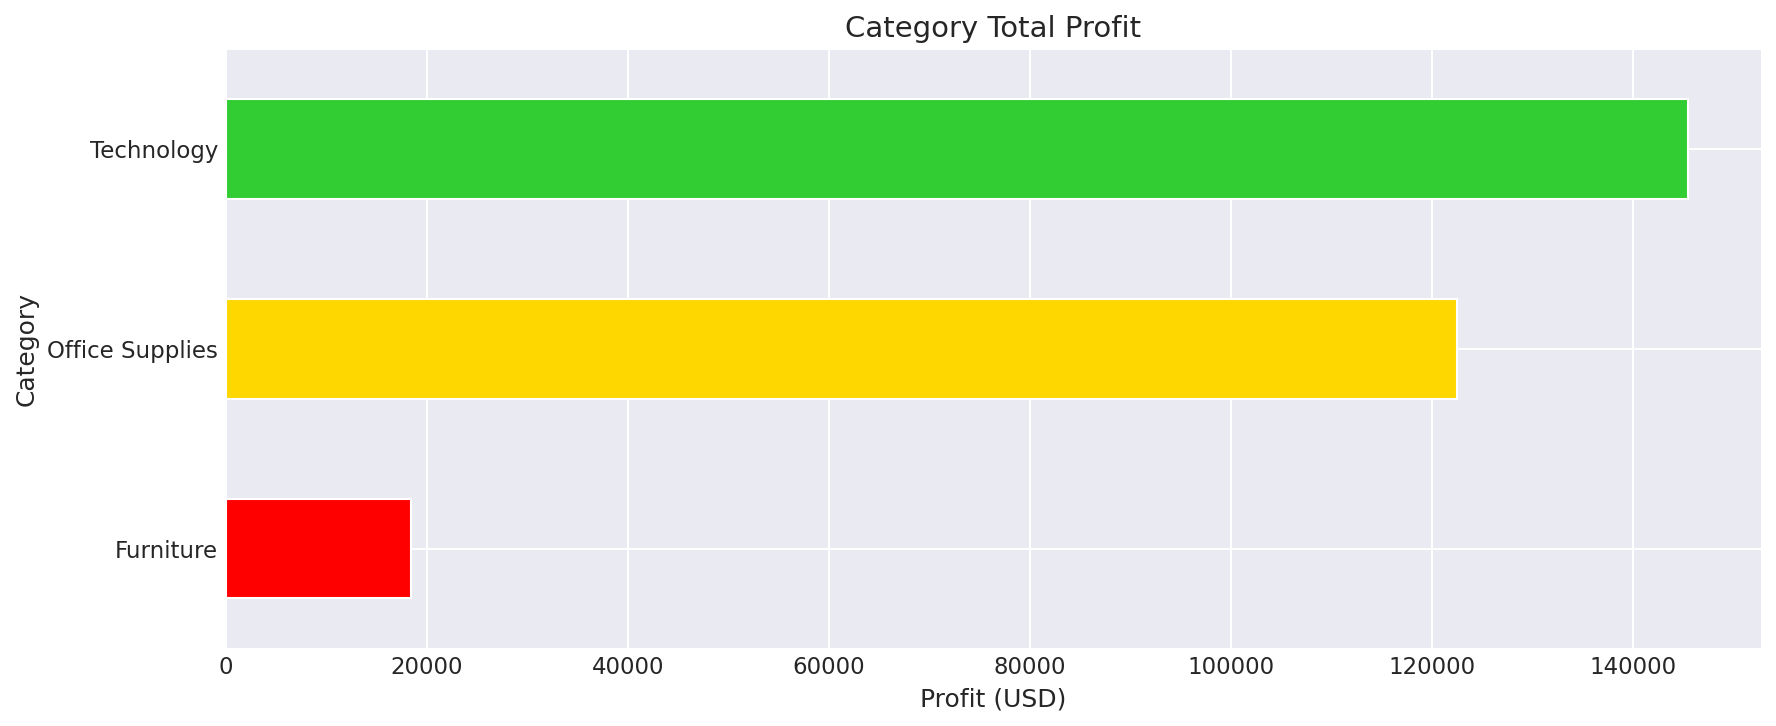

In [7]:
"We aim to identify which product categories generate the highest profit."

profit_cat = df.groupby('Category')['Profit'].sum().sort_values()

profit_cat.plot(kind='barh', color=['red','gold','limegreen'])
plt.title('Category Total Profit')
plt.xlabel('Profit (USD)')
plt.tight_layout()
plt.show()

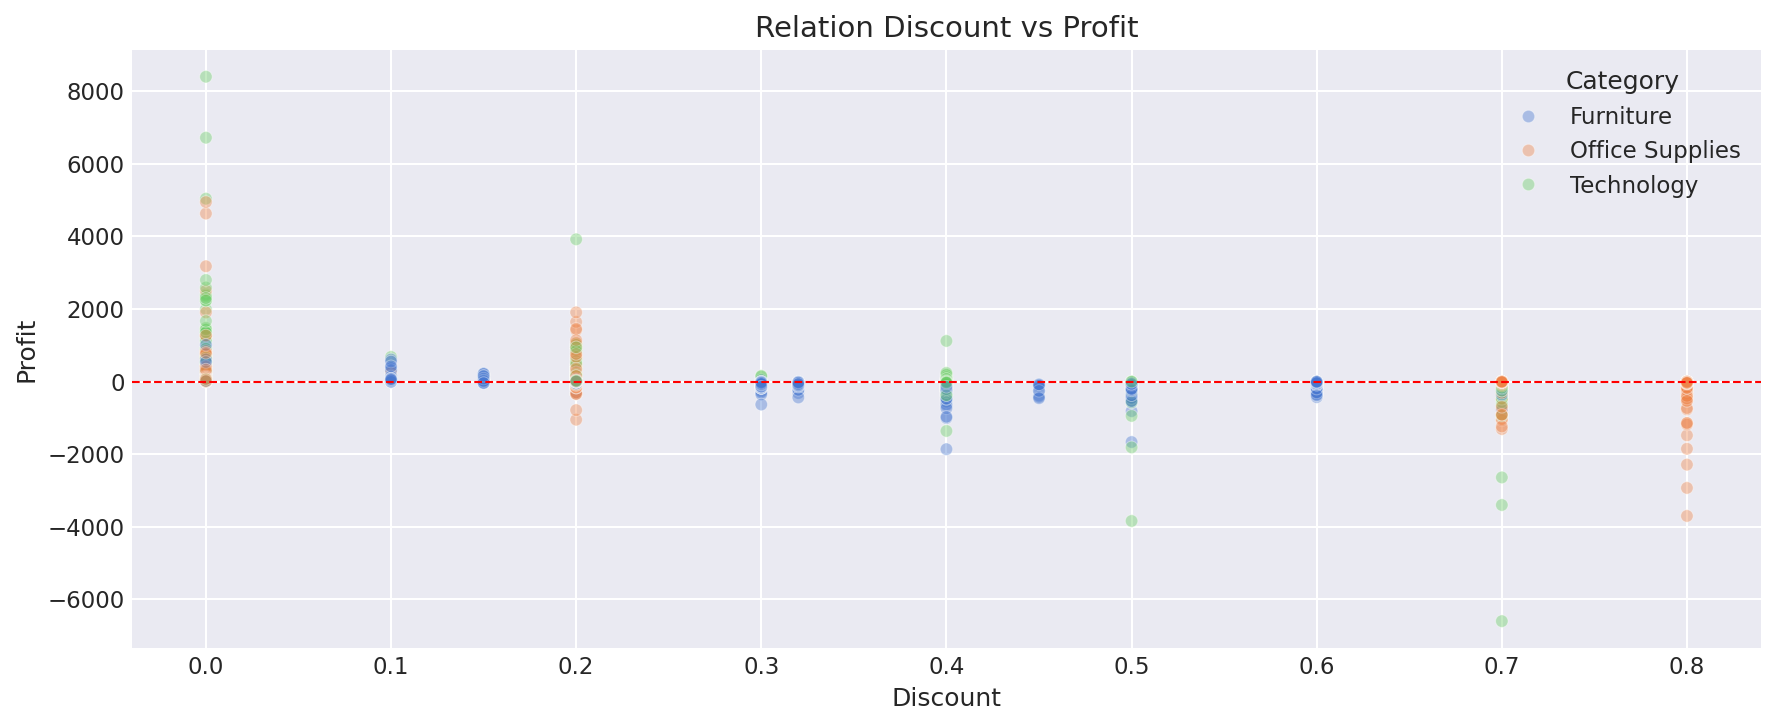

In [8]:
"We aim to explore the relationship between discounts and profit to uncover initial data insights."

sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.4, hue='Category')
plt.title('Relation Discount vs Profit')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

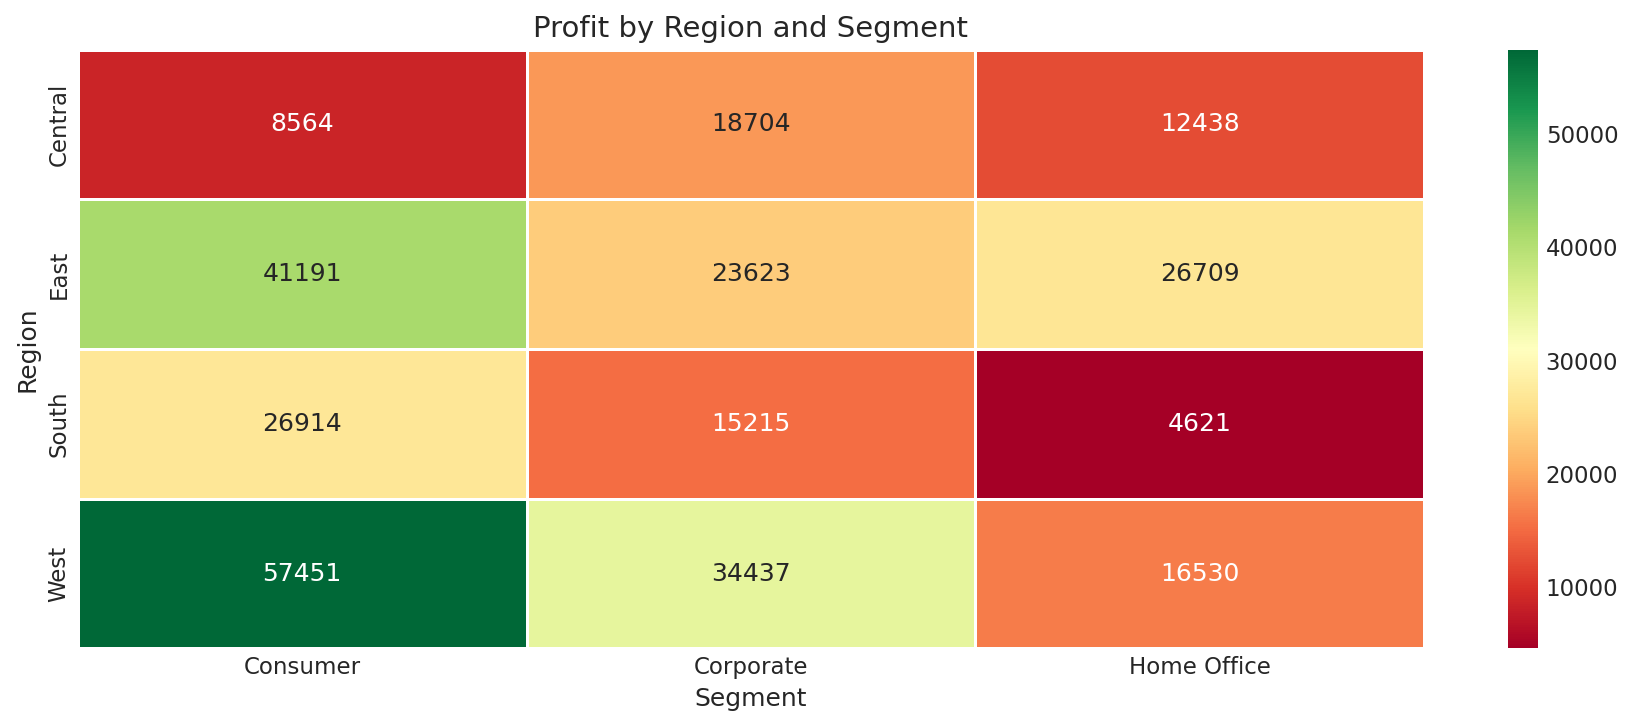

In [9]:
pivot = df.pivot_table(values='Profit', index='Region', columns='Segment', aggfunc='sum').round(0)

sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn', linewidths=0.5)
plt.title('Profit by Region and Segment')
plt.tight_layout()
plt.show()

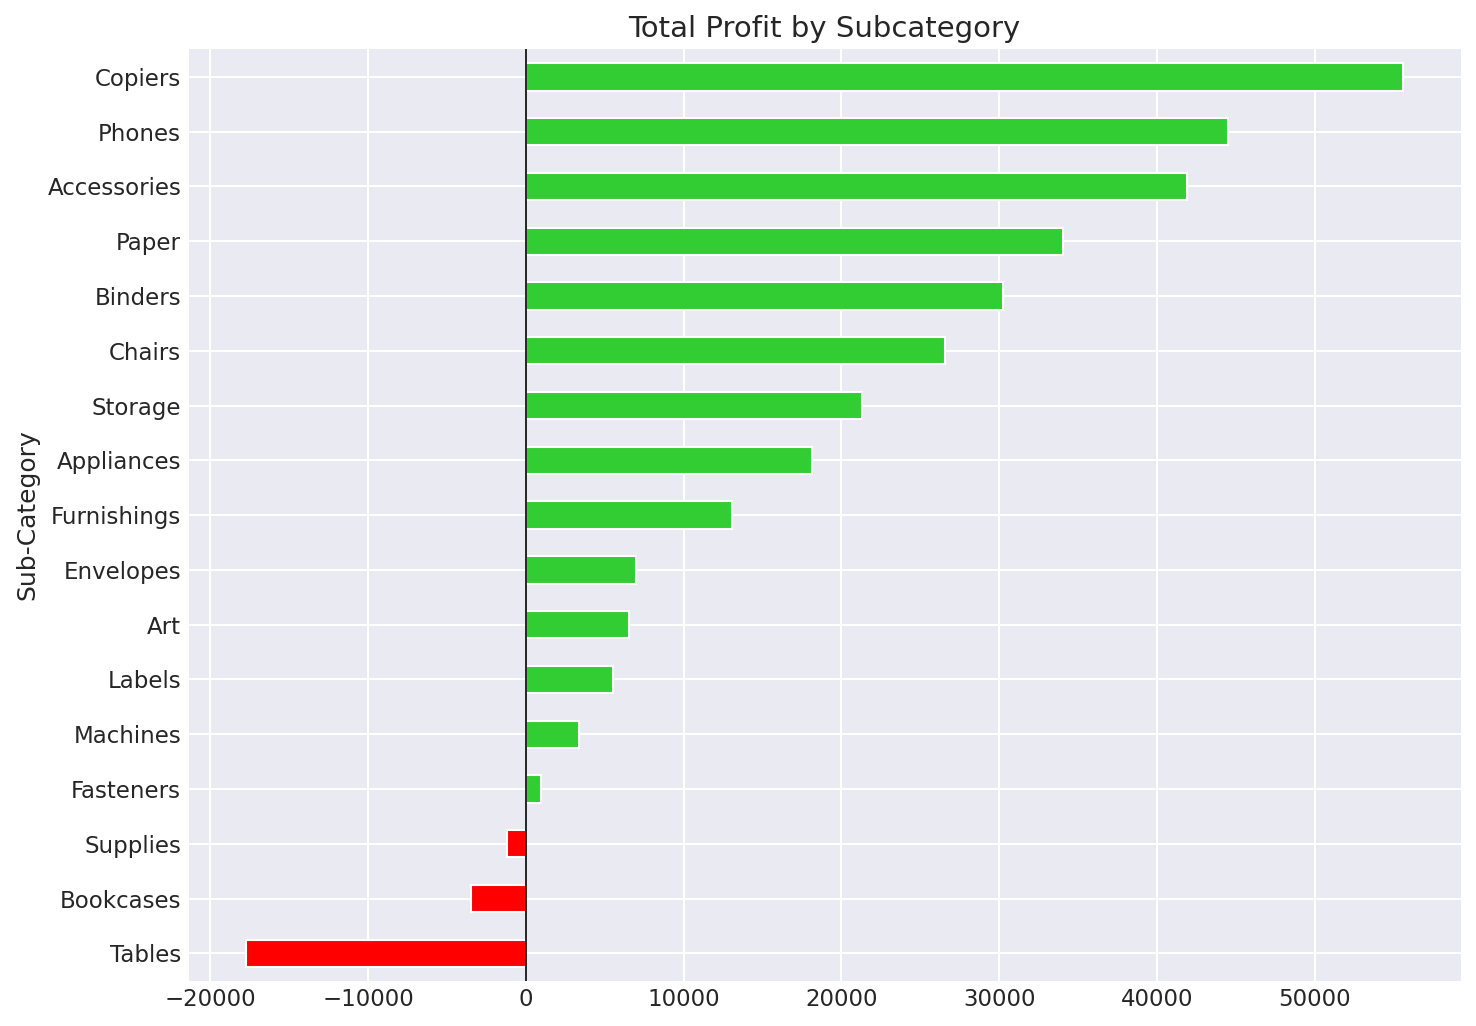

In [10]:
"A bar chart showing profit by subcategory, sorted from highest to lowest."

subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()

colors = ['red' if x < 0 else 'limegreen' for x in subcat_profit]
subcat_profit.plot(kind='barh', color=colors, figsize=(10, 7))
plt.title('Total Profit by Subcategory')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

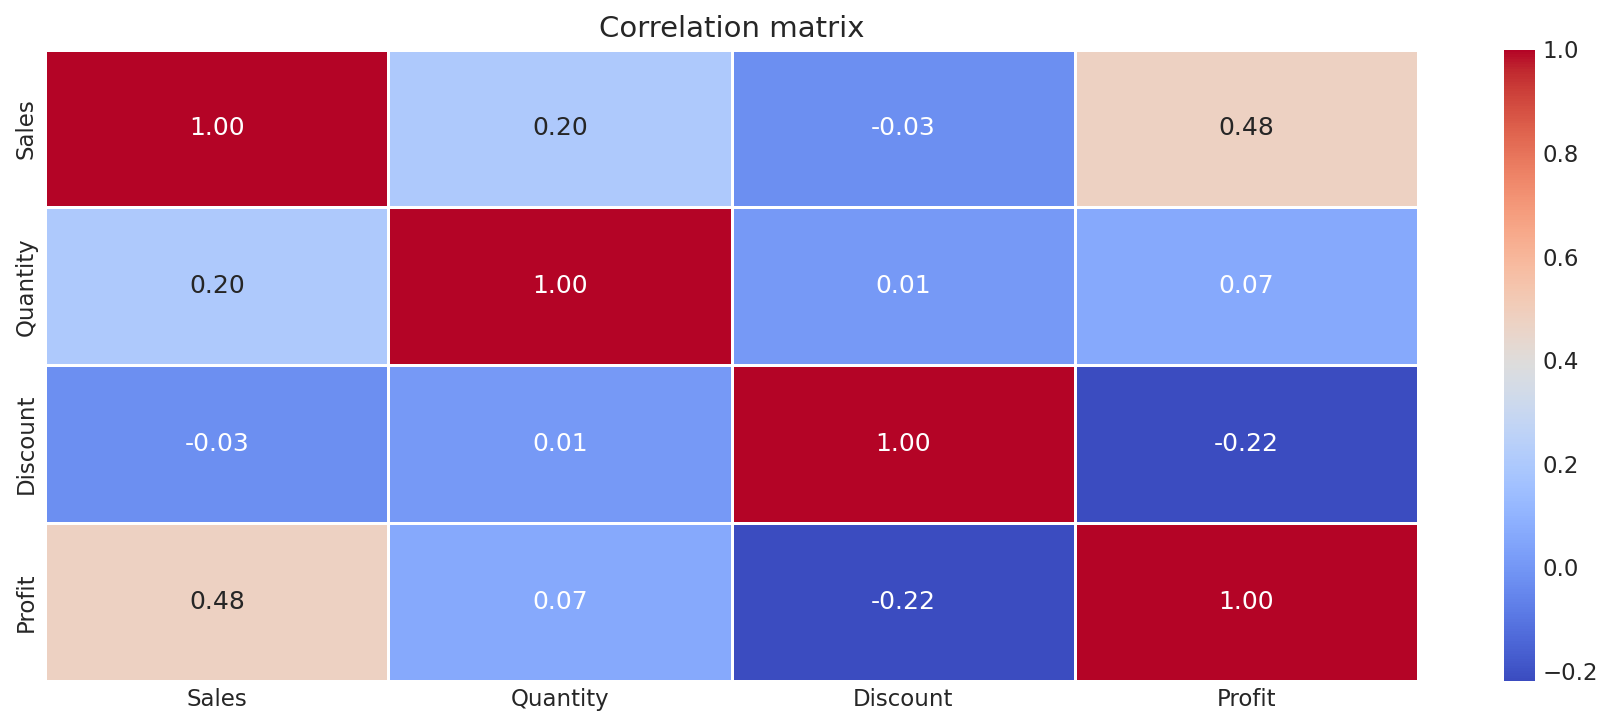

In [11]:
corr = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

In [ ]:
"Remove duplicate rows before clustering"

df = df.drop_duplicates()
print(f" Duplicates removed. Remaining rows: {df.shape[0]:,}")

 Duplicates removed. Remaining rows: 9,977


In [13]:
"Phase 2 — K-Means Segmentation"
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

print(" Clustering libraries loaded")

 Clustering libraries loaded


In [ ]:
" Select features for clustering"

features = ['Sales', 'Quantity', 'Discount', 'Profit']
X = df[features].copy()

# Scale features — KMeans is sensitive to scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f" Features scaled: {X_scaled.shape}")

 Features scaled: (9977, 4)


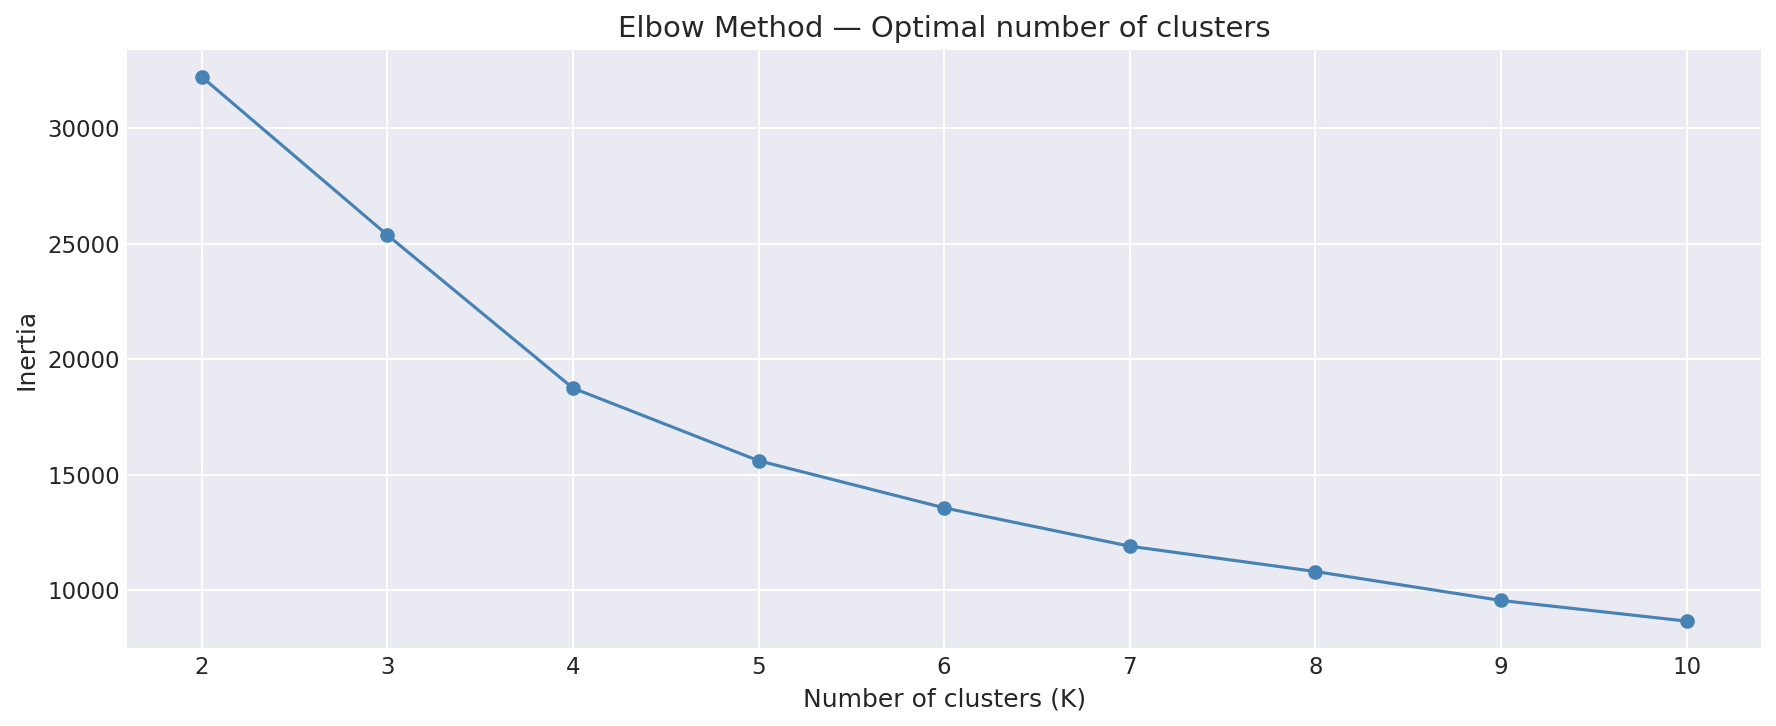

In [15]:
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(k_range, inertias, marker='o', color='steelblue')
plt.title('Elbow Method — Optimal number of clusters')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

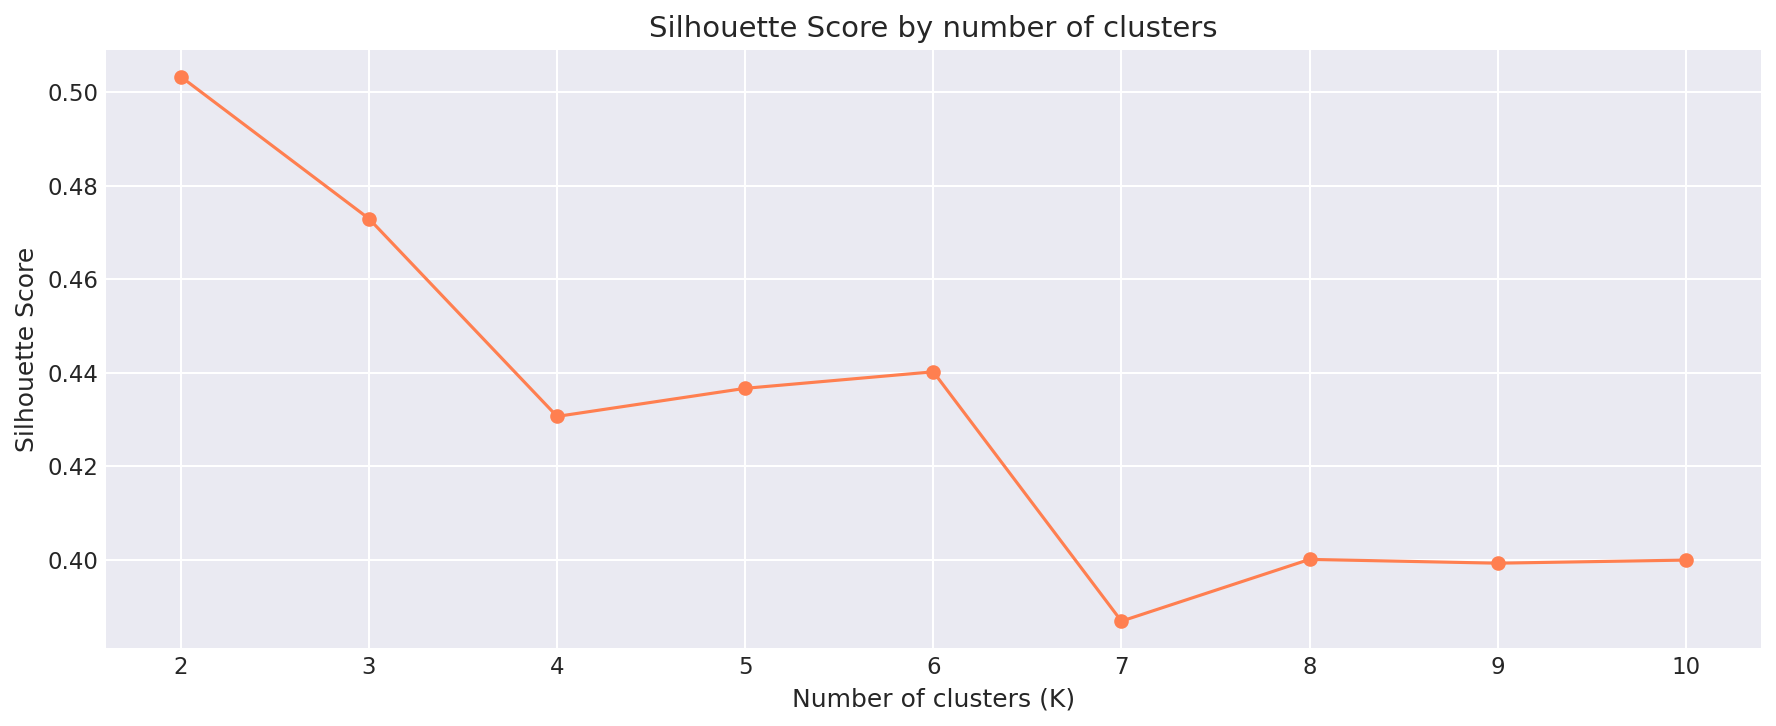

In [16]:
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    silhouettes.append(silhouette_score(X_scaled, labels))

plt.plot(k_range, silhouettes, marker='o', color='coral')
plt.title('Silhouette Score by number of clusters')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

In [ ]:
" Adjust K based on elbow and silhouette results"
K_OPTIMAL = 4

km_final = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
df['Cluster'] = km_final.fit_predict(X_scaled)

print(f" Clusters assigned with K={K_OPTIMAL}")
print(df['Cluster'].value_counts().sort_index())

 Clusters assigned with K=4
Cluster
0    6069
1    2838
2      27
3    1043
Name: count, dtype: int64


In [ ]:
"Average profile per cluster"

profile = df.groupby('Cluster')[features].mean().round(2)
print("=== AVERAGE PROFILE PER CLUSTER ===")
print(profile)

=== AVERAGE PROFILE PER CLUSTER ===
           Sales  Quantity  Discount   Profit
Cluster                                      
0         126.98      2.53      0.10    21.55
1         407.91      6.45      0.09    69.79
2        7685.18      5.19      0.07  2610.22
3         153.78      3.84      0.67  -108.40


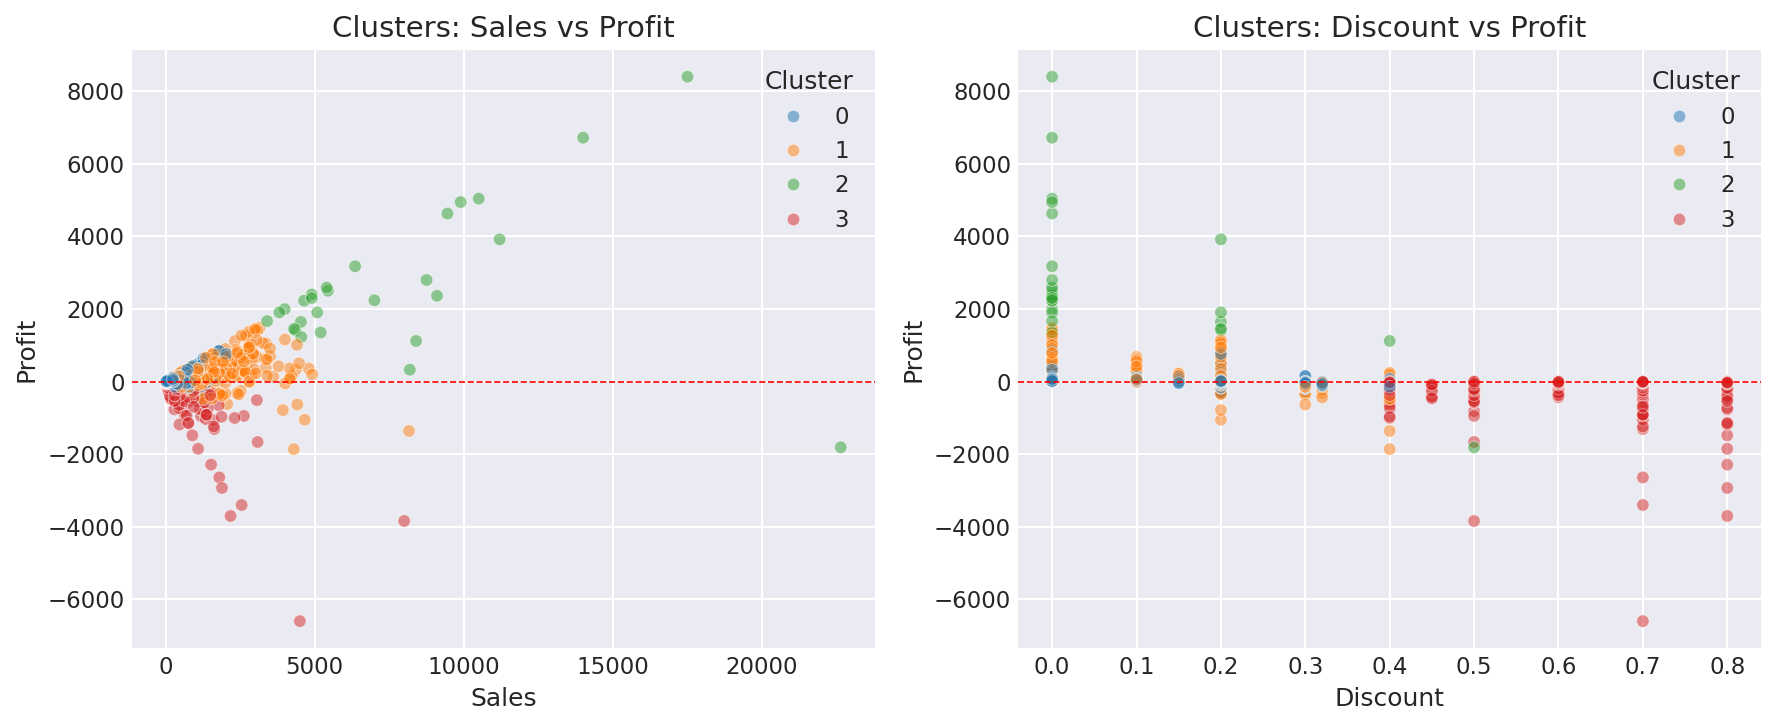

In [19]:
fig, axes = plt.subplots(1, 2)

# Sales vs Profit by cluster
sns.scatterplot(data=df, x='Sales', y='Profit',
                hue='Cluster', palette='tab10',
                alpha=0.5, ax=axes[0])
axes[0].set_title('Clusters: Sales vs Profit')
axes[0].axhline(0, color='red', linestyle='--', linewidth=0.8)

# Discount vs Profit by cluster
sns.scatterplot(data=df, x='Discount', y='Profit',
                hue='Cluster', palette='tab10',
                alpha=0.5, ax=axes[1])
axes[1].set_title('Clusters: Discount vs Profit')
axes[1].axhline(0, color='red', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

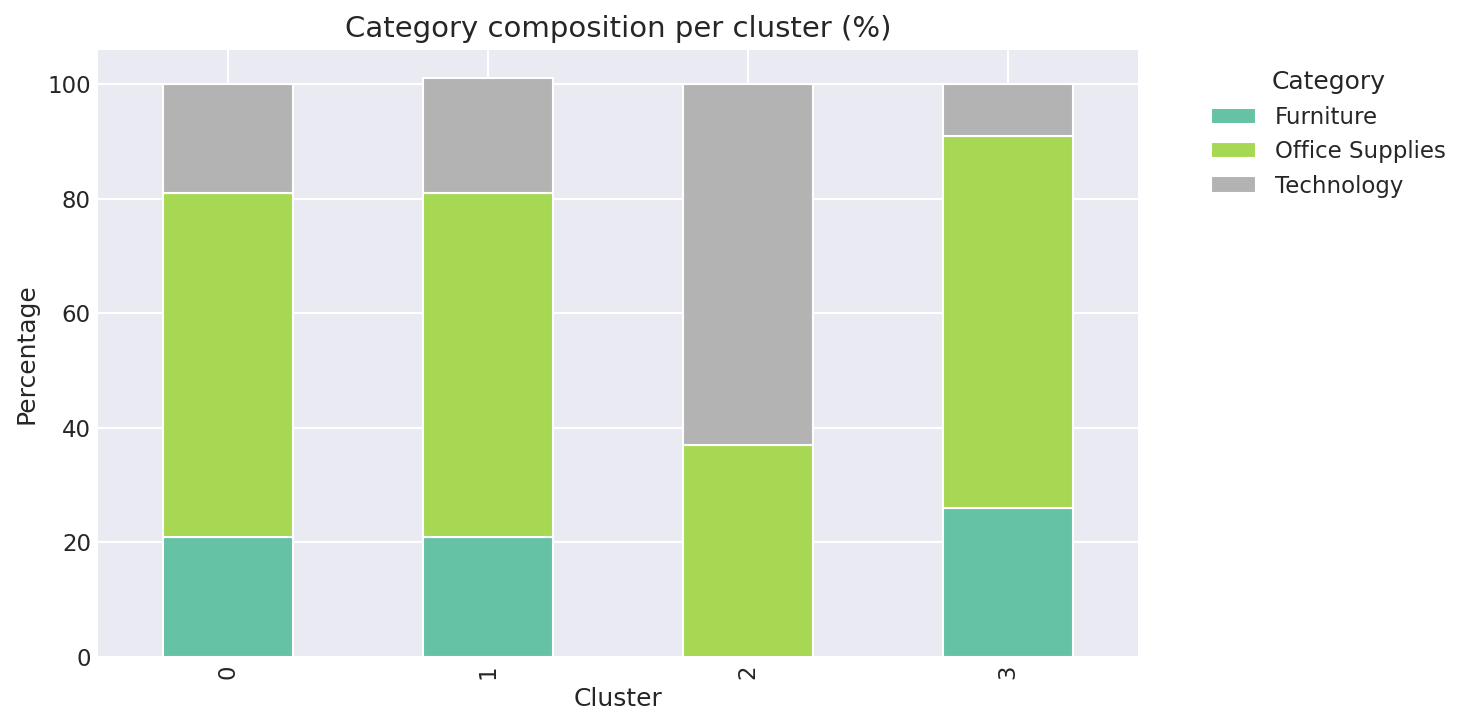

In [ ]:
" Category composition per cluster (%)"
ct = pd.crosstab(df['Cluster'], df['Category'], normalize='index').round(2) * 100

ct.plot(kind='bar', stacked=True, colormap='Set2', figsize=(10, 5))
plt.title('Category composition per cluster (%)')
plt.xlabel('Cluster')
plt.ylabel('Percentage')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [21]:
# Sub-categories with negative total profit
subcat_analysis = df.groupby('Sub-Category').agg(
    Total_Profit=('Profit', 'sum'),
    Avg_Discount=('Discount', 'mean'),
    Avg_Sales=('Sales', 'mean'),
    Transactions=('Profit', 'count')
).round(2).sort_values('Total_Profit')

# Flag losing sub-categories
subcat_analysis['Status'] = subcat_analysis['Total_Profit'].apply(
    lambda x: '🔴 Loss' if x < 0 else '🟢 Profit'
)

print("=== SUB-CATEGORY PERFORMANCE ===")
print(subcat_analysis)

=== SUB-CATEGORY PERFORMANCE ===
              Total_Profit  Avg_Discount  Avg_Sales  Transactions    Status
Sub-Category                                                               
Tables           -17725.48          0.26     648.79           319    🔴 Loss
Bookcases         -3472.56          0.21     503.86           228    🔴 Loss
Supplies          -1189.10          0.08     245.65           190    🔴 Loss
Fasteners           949.52          0.08      13.94           217  🟢 Profit
Machines           3384.76          0.31    1645.55           115  🟢 Profit
Labels             5526.38          0.07      34.28           363  🟢 Profit
Art                6524.61          0.07      34.10           795  🟢 Profit
Envelopes          6964.18          0.08      64.87           254  🟢 Profit
Furnishings       13052.72          0.14      95.90           956  🟢 Profit
Appliances        18138.01          0.17     230.76           466  🟢 Profit
Storage           21278.83          0.07     264.59    

In [22]:
# Features and target
X_reg = df[['Sales', 'Quantity', 'Discount']]
y_reg = df['Profit']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

print(" Model trained")
print(f"Intercept: {model.intercept_:.2f}")
print(f"\nCoefficients:")
for feat, coef in zip(X_reg.columns, model.coef_):
    print(f"  {feat}: {coef:.4f}")

 Model trained
Intercept: 35.02

Coefficients:
  Sales: 0.1815
  Quantity: -3.0713
  Discount: -231.2429


In [23]:
# Filter losing sub-categories
losing_subcats = subcat_analysis[subcat_analysis['Total_Profit'] < 0].index.tolist()
df_loss = df[df['Sub-Category'].isin(losing_subcats)].copy()

# Simulate discount reduction scenarios
scenarios = {
    'Current':       df_loss['Discount'],
    'Discount -20%': (df_loss['Discount'] * 0.8).clip(0, 0.8),
    'Discount -40%': (df_loss['Discount'] * 0.6).clip(0, 0.8),
    'No Discount':   pd.Series(0, index=df_loss.index)
}

results = {}
for scenario, discount_values in scenarios.items():
    X_sim = df_loss[['Sales', 'Quantity']].copy()
    X_sim['Discount'] = discount_values
    predicted_profit = model.predict(X_sim)
    results[scenario] = predicted_profit.sum().round(0)

print("=== DISCOUNT SIMULATION — LOSING SUB-CATEGORIES ===")
for scenario, total in results.items():
    print(f"  {scenario}: ${total:,.0f}")

=== DISCOUNT SIMULATION — LOSING SUB-CATEGORIES ===
  Current: $50,450
  Discount -20%: $57,207
  Discount -40%: $63,963
  No Discount: $84,233


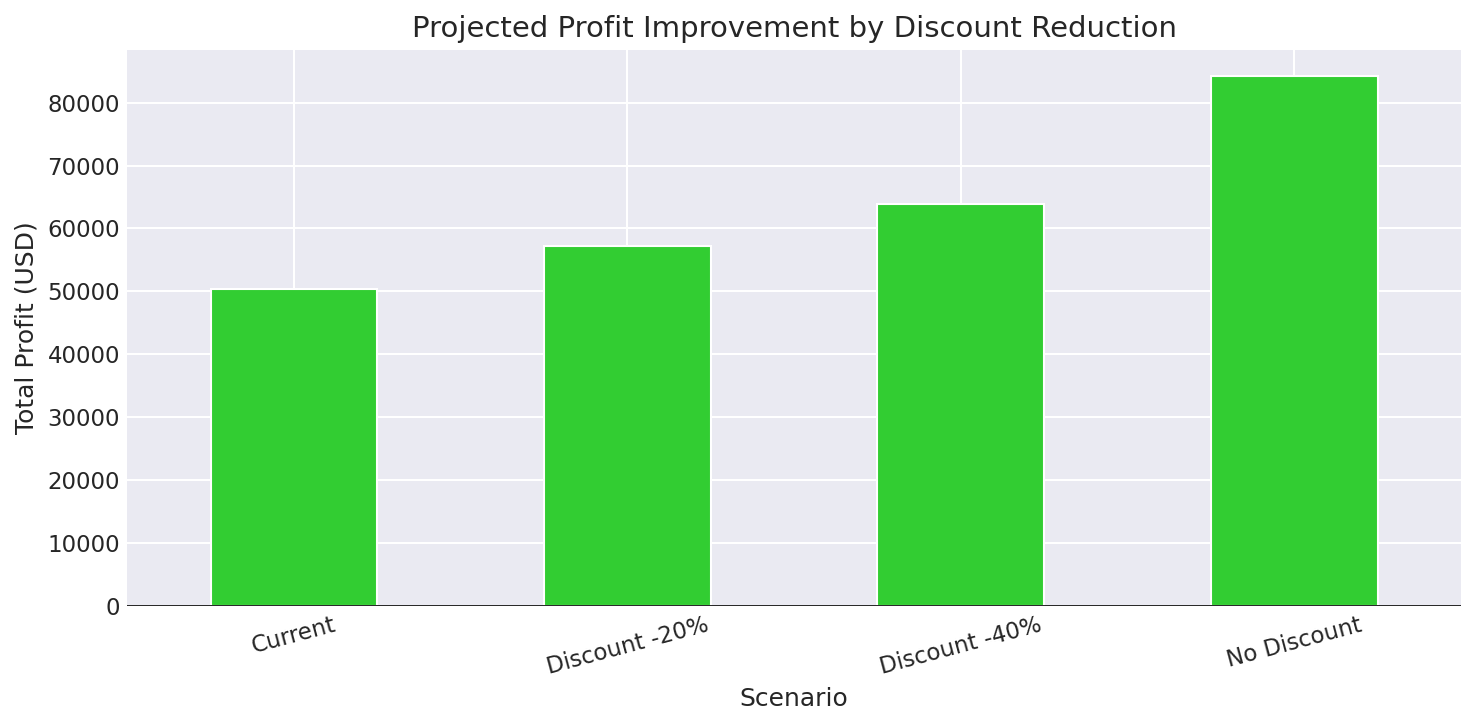

In [24]:
scenarios_df = pd.DataFrame({
    'Scenario': list(results.keys()),
    'Total Profit': list(results.values())
})

colors = ['red' if v < 0 else 'limegreen' for v in scenarios_df['Total Profit']]
scenarios_df.plot(kind='bar', x='Scenario', y='Total Profit',
                  color=colors, legend=False, figsize=(10, 5))

plt.title('Projected Profit Improvement by Discount Reduction')
plt.xlabel('Scenario')
plt.ylabel('Total Profit (USD)')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [25]:
"Phase 4 — Model Evaluation"
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== MODEL EVALUATION ===")
print(f"R² Score:              {r2:.4f}")
print(f"Mean Absolute Error:   ${mae:.2f}")
print(f"Intercept:             {model.intercept_:.2f}")

=== MODEL EVALUATION ===
R² Score:              0.1741
Mean Absolute Error:   $59.80
Intercept:             35.02


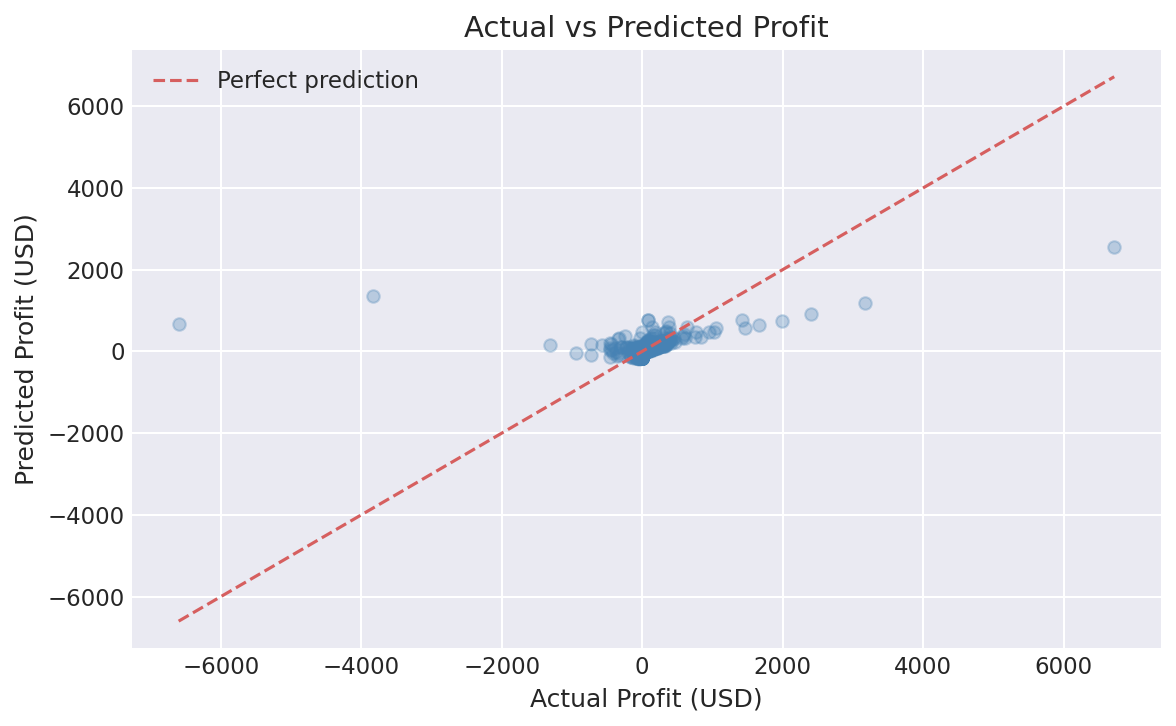

In [26]:
# Actual vs Predicted scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=1.5, label='Perfect prediction')
plt.title('Actual vs Predicted Profit')
plt.xlabel('Actual Profit (USD)')
plt.ylabel('Predicted Profit (USD)')
plt.legend()
plt.tight_layout()
plt.show()

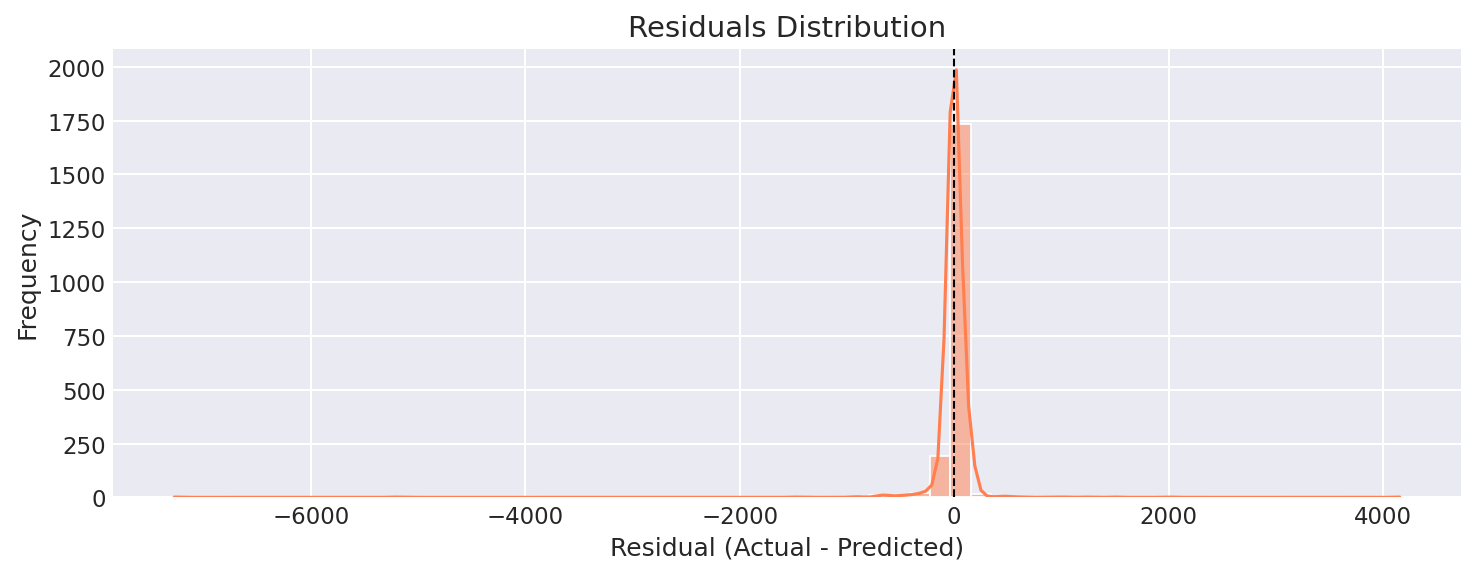

Mean residual: -1.62
Std residual:  250.92


In [27]:
# Residuals = difference between actual and predicted
residuals = y_test - y_pred

plt.figure(figsize=(10, 4))
sns.histplot(residuals, bins=60, kde=True, color='coral')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('Residuals Distribution')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Mean residual: {residuals.mean():.2f}")
print(f"Std residual:  {residuals.std():.2f}")

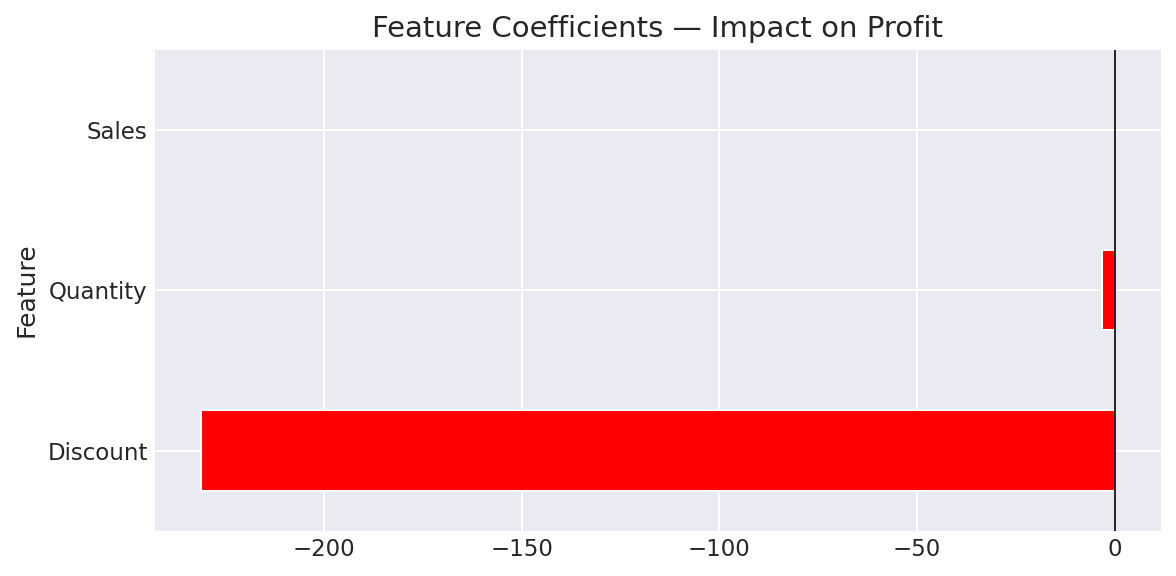

In [28]:
# Visualize model coefficients
coef_df = pd.DataFrame({
    'Feature': X_reg.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient')

colors = ['red' if c < 0 else 'green' for c in coef_df['Coefficient']]
coef_df.plot(kind='barh', x='Feature', y='Coefficient',
             color=colors, legend=False, figsize=(8, 4))
plt.title('Feature Coefficients — Impact on Profit')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [29]:
print("=== BUSINESS INTERPRETATION ===")
print(f"""
Model Performance:
  - R² Score: {r2:.4f} — the model explains {r2*100:.1f}% of profit variance
  - MAE: ${mae:.2f} — average prediction error per transaction

Key Drivers of Profit (from coefficients):
  - Discount has the strongest NEGATIVE impact (-$231 per unit increase)
  - Sales has a positive but modest impact (+$0.18 per dollar sold)
  - Quantity alone does not guarantee profit (-$3.07 per unit)

Business Recommendation:
  - Eliminating discounts on losing sub-categories (Tables, Bookcases, Supplies)
    could increase their combined profit from $50,450 to $84,233 (+67%)
  - Priority action: Review discount policy for Tables (-$17,725 total loss)
""")

=== BUSINESS INTERPRETATION ===

Model Performance:
  - R² Score: 0.1741 — the model explains 17.4% of profit variance
  - MAE: $59.80 — average prediction error per transaction

Key Drivers of Profit (from coefficients):
  - Discount has the strongest NEGATIVE impact (-$231 per unit increase)
  - Sales has a positive but modest impact (+$0.18 per dollar sold)
  - Quantity alone does not guarantee profit (-$3.07 per unit)

Business Recommendation:
  - Eliminating discounts on losing sub-categories (Tables, Bookcases, Supplies)
    could increase their combined profit from $50,450 to $84,233 (+67%)
  - Priority action: Review discount policy for Tables (-$17,725 total loss)

